In [1]:
%pip install -q pandas numpy scikit-learn matplotlib seaborn


In [2]:
import numpy as np
import pandas as pd

from IPython.display import display

rng = np.random.default_rng(42)
n = 2500

df = pd.DataFrame({
    "elapsed_hours": np.clip(
        rng.lognormal(2.5, 0.85, n), 0.5, 120
    ),
    "approver_workload": rng.integers(1, 21, n),
    "complexity": rng.integers(1, 6, n),
    "missing_documents": rng.binomial(1, 0.20, n),
    "stage": rng.choice(
        ["Submitted", "Manager Review",
         "Finance Review", "Final Approval"], n
    ),
    "priority": rng.choice(
        ["Low", "Medium", "High", "Critical"], n
    ),
    "department": rng.choice(
        ["IT", "Finance", "HR", "Operations",
         "Procurement"], n
    ),
    "request_type": rng.choice(
        ["Purchase", "Invoice", "Onboarding",
         "Access Request", "Equipment"], n
    ),
})

stage_effect = df["stage"].map({
    "Submitted": 0.0,
    "Manager Review": 0.25,
    "Finance Review": 0.55,
    "Final Approval": 0.45,
})

priority_effect = df["priority"].map({
    "Low": 0.0,
    "Medium": 0.20,
    "High": 0.55,
    "Critical": 0.75,
})

log_odds = (
    -3.0
    + 0.035 * df["elapsed_hours"]
    + 0.10 * df["approver_workload"]
    + 0.25 * df["complexity"]
    + 0.85 * df["missing_documents"]
    + stage_effect
    + priority_effect
)

probability = 1 / (1 + np.exp(-log_odds))

df["sla_breached"] = rng.binomial(1, probability)

df["created_at"] = pd.date_range(
    "2025-01-01", periods=n, freq="6h"
)

df["request_id"] = [
    f"WP-{i:05d}" for i in range(1, n + 1)
]

print("Dataset created successfully!")
print("Number of workflows:", len(df))
display(df.head())


Dataset created successfully!
Number of workflows: 2500


,elapsed_hours,approver_workload,complexity,missing_documents,stage,priority,department,request_type,sla_breached,created_at,request_id
0,15.784201,20,3,0,Submitted,Critical,Operations,Onboarding,1,2025-01-01 00:00:00,WP-00001
1,5.032986,1,4,0,Manager Review,Low,IT,Invoice,0,2025-01-01 06:00:00,WP-00002
2,23.055020,5,4,0,Finance Review,Low,Procurement,Equipment,1,2025-01-01 12:00:00,WP-00003
3,27.098544,6,4,0,Manager Review,Critical,Finance,Equipment,1,2025-01-01 18:00:00,WP-00004
4,2.320123,6,4,0,Finance Review,Medium,Operations,Onboarding,0,2025-01-02 00:00:00,WP-00005


Model training completed!
               precision    recall  f1-score   support

No SLA breach       0.63      0.65      0.64       236
   SLA breach       0.68      0.66      0.67       264

     accuracy                           0.65       500
    macro avg       0.65      0.65      0.65       500
 weighted avg       0.65      0.65      0.65       500

ROC-AUC: 0.691


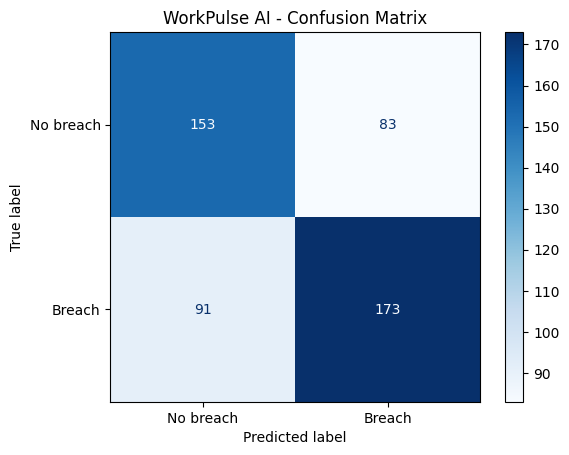

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

numeric_features = [
    "elapsed_hours",
    "approver_workload",
    "complexity",
    "missing_documents",
]

categorical_features = [
    "stage",
    "priority",
    "department",
    "request_type",
]

features = numeric_features + categorical_features

# Sort chronologically before splitting.
df = df.sort_values("created_at").reset_index(drop=True)

split = int(len(df) * 0.80)

train_df = df.iloc[:split]
test_df = df.iloc[split:]

X_train = train_df[features]
y_train = train_df["sla_breached"]

X_test = test_df[features]
y_test = test_df["sla_breached"]

preprocessor = ColumnTransformer([
    (
        "numeric",
        StandardScaler(),
        numeric_features,
    ),
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features,
    ),
])

model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42,
        ),
    ),
])

model.fit(X_train, y_train)

predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]

print("Model training completed!")
print(classification_report(
    y_test,
    predictions,
    target_names=["No SLA breach", "SLA breach"],
    zero_division=0,
))

print("ROC-AUC:", round(
    roc_auc_score(y_test, probabilities), 3
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=["No breach", "Breach"],
    cmap="Blues",
)
plt.title("WorkPulse AI - Confusion Matrix")
plt.show()


In [4]:
import ipywidgets as widgets
from IPython.display import display, clear_output

elapsed = widgets.FloatSlider(
    value=24, min=0.5, max=120,
    step=0.5, description="Waiting hours:"
)

workload = widgets.IntSlider(
    value=10, min=1, max=20,
    description="Workload:"
)

complexity = widgets.IntSlider(
    value=3, min=1, max=5,
    description="Complexity:"
)

missing = widgets.Dropdown(
    options=[("No", 0), ("Yes", 1)],
    value=0, description="Missing docs:"
)

stage = widgets.Dropdown(
    options=[
        "Submitted", "Manager Review",
        "Finance Review", "Final Approval"
    ],
    description="Stage:"
)

priority = widgets.Dropdown(
    options=["Low", "Medium", "High", "Critical"],
    value="Medium", description="Priority:"
)

department = widgets.Dropdown(
    options=[
        "IT", "Finance", "HR",
        "Operations", "Procurement"
    ],
    description="Department:"
)

request_type = widgets.Dropdown(
    options=[
        "Purchase", "Invoice", "Onboarding",
        "Access Request", "Equipment"
    ],
    description="Request type:"
)

output = widgets.Output()

def predict_risk(_=None):
    with output:
        clear_output(wait=True)

        sample = pd.DataFrame([{
            "elapsed_hours": elapsed.value,
            "approver_workload": workload.value,
            "complexity": complexity.value,
            "missing_documents": missing.value,
            "stage": stage.value,
            "priority": priority.value,
            "department": department.value,
            "request_type": request_type.value,
        }])[features]

        risk = model.predict_proba(sample)[0, 1]

        print(f"Predicted SLA breach risk: {risk:.1%}")

        if risk >= 0.5:
            print("Status: Flag for human review")
        else:
            print("Status: Below the demo alert threshold")

        print(
            "Note: This prediction uses synthetic training data "
            "and is not a validated corporate risk estimate."
        )

button = widgets.Button(
    description="Predict Risk",
    button_style="primary",
    icon="check",
)

button.on_click(predict_risk)

display(widgets.VBox([
    elapsed,
    workload,
    complexity,
    missing,
    stage,
    priority,
    department,
    request_type,
    button,
    output,
]))


In [5]:
%pip install -q ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 35.9 MB/s eta 0:00:00


In [6]:
import joblib

joblib.dump(model, "workpulse_model.joblib")
df.to_csv("workpulse_dataset.csv", index=False)

print("Saved model and dataset!")

Saved model and dataset!
